#IMPORT LIBRARY

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
import statsmodels.api as sm

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import warnings
warnings.filterwarnings("ignore")

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#LOAD & PREPROCESS DATA

In [2]:
df = pd.read_csv(
    "/content/drive/MyDrive/snapshots_2025-07-03_ID-2024-hourly.csv"
)

df = df.rename(columns={
    "Datetime (UTC)": "datetime",
    "Carbon intensity gCO₂eq/kWh (direct)": "carbon_intensity"
})

df["datetime"] = pd.to_datetime(df["datetime"])
df = df.set_index("datetime")

df = df[[
    "carbon_intensity",
    "Carbon-free energy percentage (CFE%)"
]]

df.head()


,carbon_intensity,Carbon-free energy percentage (CFE%)
datetime,,
2024-01-01 00:00:00,572.49,18.91
2024-01-01 01:00:00,568.43,18.87
2024-01-01 02:00:00,562.75,19.32
2024-01-01 03:00:00,567.29,18.85
2024-01-01 04:00:00,568.28,18.74


#AGREGASI MUSIMAN (DAILY)

In [3]:
df_daily = df.resample("D").mean()
df_daily = df_daily.interpolate()

df_daily.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 366 entries, 2024-01-01 to 2024-12-31
Freq: D
Data columns (total 2 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   carbon_intensity                      366 non-null    float64
 1   Carbon-free energy percentage (CFE%)  366 non-null    float64
dtypes: float64(2)
memory usage: 8.6 KB


#STATISTIK DESKRIPTIF

In [4]:
df_daily.describe().T


,count,mean,std,min,25%,50%,75%,max
carbon_intensity,366.0,566.952971,7.759439,548.574583,561.345417,565.705625,571.628333,587.57375
Carbon-free energy percentage (CFE%),366.0,18.194333,1.015809,15.372083,17.463333,18.224167,18.891562,21.01875


#VISUALISASI DERET WAKTU

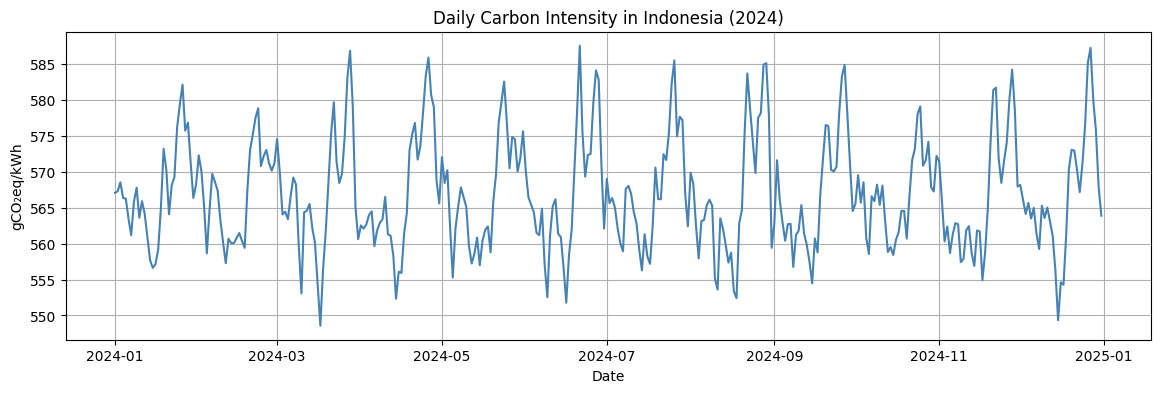

In [5]:
plt.figure(figsize=(14,4))
plt.plot(df_daily["carbon_intensity"], color="steelblue")
plt.title("Daily Carbon Intensity in Indonesia (2024)")
plt.xlabel("Date")
plt.ylabel("gCO₂eq/kWh")
plt.grid(True)
plt.show()

#DEKOMPOSISI MUSIMAN

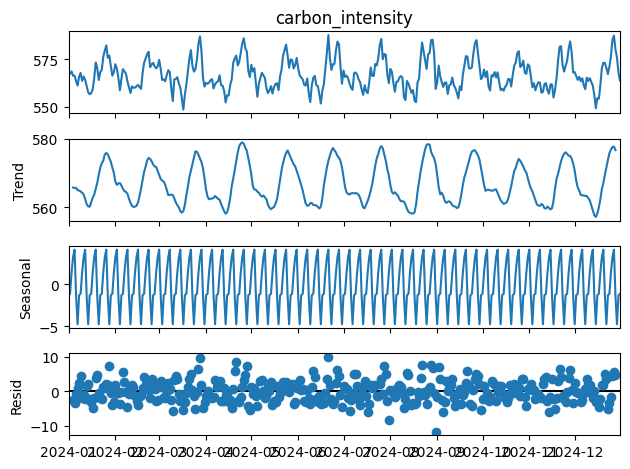

In [6]:
decomp = seasonal_decompose(df_daily["carbon_intensity"], period=7)
decomp.plot()
plt.show()


#UJI STASIONERITAS (ADF)

In [7]:
y = df_daily["carbon_intensity"]

adf_stat, p_value, *_ = adfuller(y)

print("ADF Statistic:", adf_stat)
print("p-value:", p_value)

ADF Statistic: -9.278440268033469
p-value: 1.2701941229721602e-15


#ACF & PACF

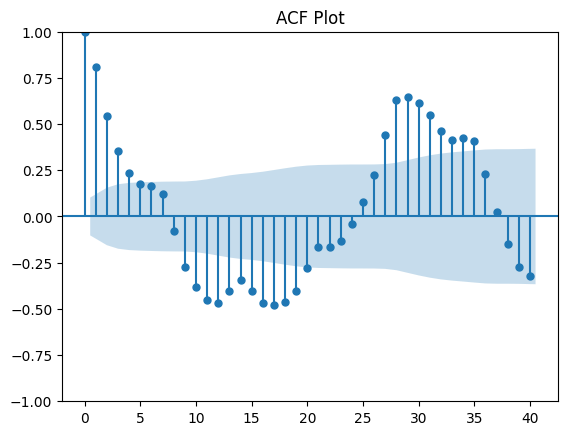

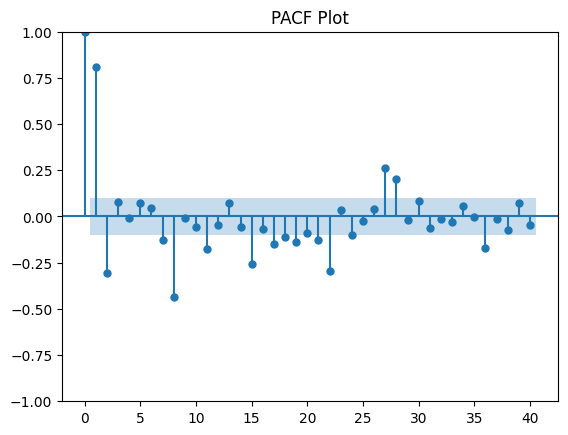

In [8]:
plot_acf(y, lags=40)
plt.title("ACF Plot")
plt.show()

plot_pacf(y, lags=40)
plt.title("PACF Plot")
plt.show()

#FUNGSI EVALUASI

In [9]:
def evaluate(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return mae, rmse, mape

#FUNGSI SPLIT DATA BERDASARKAN HORIZON

In [10]:
def split_data(y, exog, horizon):
    y_train = y.iloc[:-horizon]
    y_test  = y.iloc[-horizon:]

    exog_train = exog.iloc[:-horizon]
    exog_test  = exog.iloc[-horizon:]

    scaler = StandardScaler()
    exog_train_s = scaler.fit_transform(exog_train)
    exog_test_s  = scaler.transform(exog_test)

    return y_train, y_test, exog_train_s, exog_test_s

#SET HORIZON PENGUJIAN

In [11]:
exog = df_daily[["Carbon-free energy percentage (CFE%)"]]

HORIZONS = {
    "Short": 30,
    "Long": 90
}

#MODEL 1: SARIMAX (SHORT & LONG)


===== SARIMAX Short-Term =====
                                     SARIMAX Results                                     
Dep. Variable:                  carbon_intensity   No. Observations:                  336
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 7)   Log Likelihood                -662.088
Date:                           Sun, 04 Jan 2026   AIC                           1336.175
Time:                                   12:28:44   BIC                           1358.915
Sample:                               01-01-2024   HQIC                          1345.249
                                    - 12-01-2024                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1            -7.2927      0.266    -27.454      0.000      -7.813      -6.772
ar.L1      

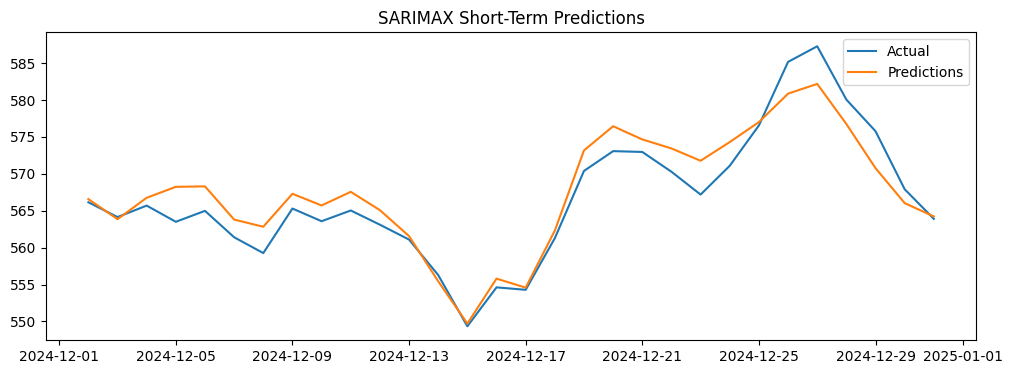


===== SARIMAX Long-Term =====
                                     SARIMAX Results                                     
Dep. Variable:                  carbon_intensity   No. Observations:                  276
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 7)   Log Likelihood                -547.198
Date:                           Sun, 04 Jan 2026   AIC                           1106.395
Time:                                   12:28:45   BIC                           1127.919
Sample:                               01-01-2024   HQIC                          1115.041
                                    - 10-02-2024                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1            -7.4002      0.300    -24.656      0.000      -7.988      -6.812
ar.L1       

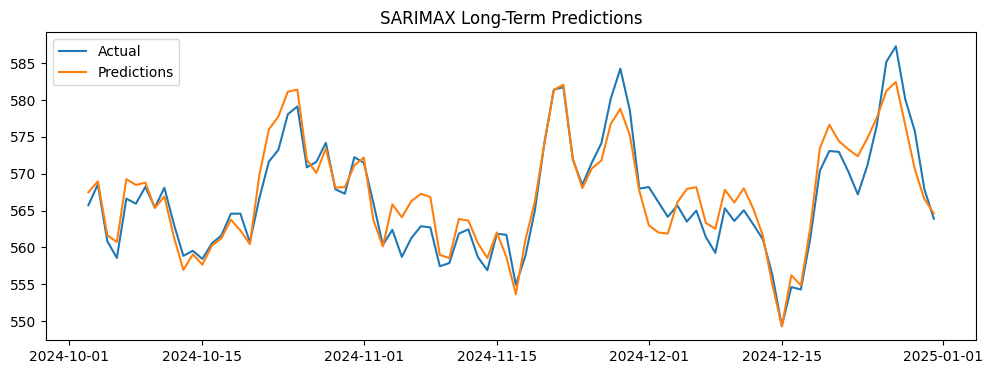

In [12]:
results = []
for label, h in HORIZONS.items():
    print(f"\n===== SARIMAX {label}-Term =====")

    y_train, y_test, exog_train, exog_test = split_data(y, exog, h)

    model = SARIMAX(
        y_train,
        exog=exog_train,
        order=(1,0,1),
        seasonal_order=(1,0,1,7),
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    res = model.fit()

    print(res.summary())  # <<< INI YANG SEBELUMNYA HILANG

    pred = res.predict(
        start=y_test.index[0],
        end=y_test.index[-1],
        exog=exog_test
    )

    mae, rmse, mape = evaluate(y_test, pred)
    results.append(["SARIMAX", label, mae, rmse, mape])

    plt.figure(figsize=(12,4))
    plt.plot(y_test, label="Actual")
    plt.plot(pred, label="Predictions")
    plt.title(f"SARIMAX {label}-Term Predictions")
    plt.legend()
    plt.show()

#MODEL 2: TIME SERIES REGRESSION (SHORT & LONG)


===== TSR Short-Term =====
                            OLS Regression Results                            
Dep. Variable:       carbon_intensity   R-squared:                       0.912
Model:                            OLS   Adj. R-squared:                  0.911
Method:                 Least Squares   F-statistic:                     842.6
Date:                Sun, 04 Jan 2026   Prob (F-statistic):          8.70e-170
Time:                        12:28:46   Log-Likelihood:                -740.18
No. Observations:                 329   AIC:                             1490.
Df Residuals:                     324   BIC:                             1509.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                           coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------

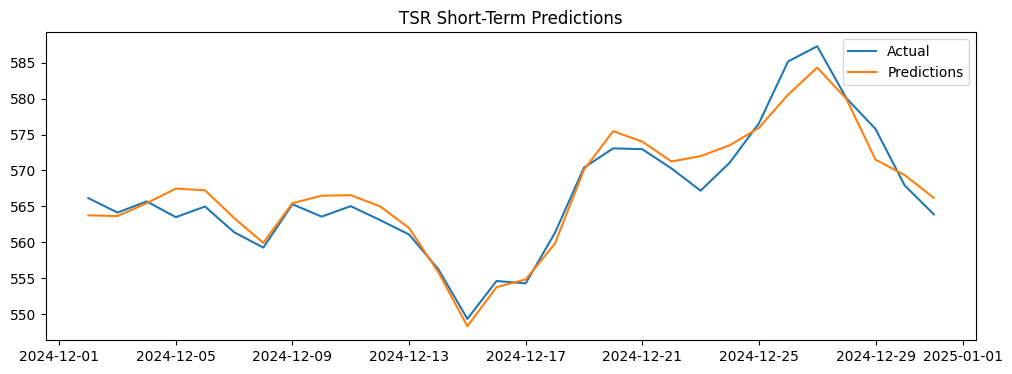


===== TSR Long-Term =====
                            OLS Regression Results                            
Dep. Variable:       carbon_intensity   R-squared:                       0.914
Model:                            OLS   Adj. R-squared:                  0.913
Method:                 Least Squares   F-statistic:                     700.3
Date:                Sun, 04 Jan 2026   Prob (F-statistic):          3.34e-139
Time:                        12:28:46   Log-Likelihood:                -607.94
No. Observations:                 269   AIC:                             1226.
Df Residuals:                     264   BIC:                             1244.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                           coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------

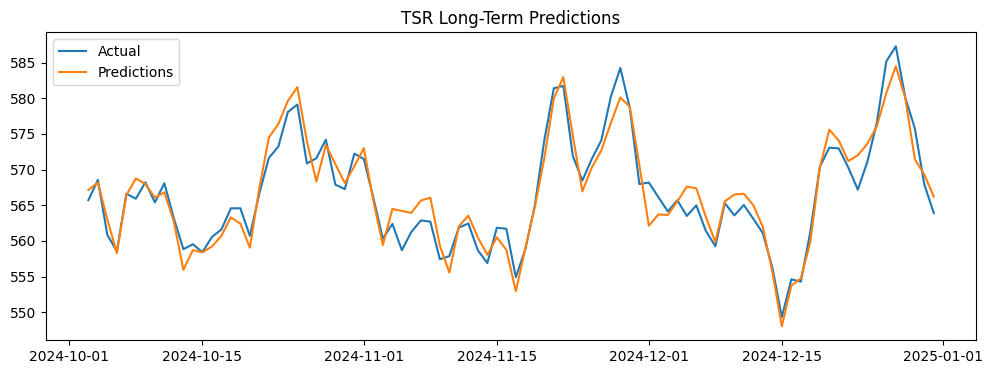

In [13]:
df_tsr = df_daily.copy()
df_tsr["t"] = np.arange(len(df_tsr))
df_tsr["lag_1"] = df_tsr["carbon_intensity"].shift(1)
df_tsr["lag_7"] = df_tsr["carbon_intensity"].shift(7)
df_tsr = df_tsr.dropna()

for label, h in HORIZONS.items():
    print(f"\n===== TSR {label}-Term =====")

    train = df_tsr.iloc[:-h]
    test  = df_tsr.iloc[-h:]

    X_train = sm.add_constant(
        train[["t","lag_1","lag_7","Carbon-free energy percentage (CFE%)"]]
    )
    y_train = train["carbon_intensity"]

    X_test = sm.add_constant(
        test[["t","lag_1","lag_7","Carbon-free energy percentage (CFE%)"]]
    )
    y_test = test["carbon_intensity"]

    model = sm.OLS(y_train, X_train).fit()

    print(model.summary())  # <<< INI JUGA PENTING

    pred = model.predict(X_test)

    mae, rmse, mape = evaluate(y_test, pred)
    results.append(["TSR", label, mae, rmse, mape])

    plt.figure(figsize=(12,4))
    plt.plot(y_test, label="Actual")
    plt.plot(pred, label="Predictions")
    plt.title(f"TSR {label}-Term Predictions")
    plt.legend()
    plt.show()


#MODEL 3: HYBRID (SARIMAX + TSR RESIDUAL)


===== HYBRID Short-Term =====
SARIMAX BASE MODEL SUMMARY
                                     SARIMAX Results                                     
Dep. Variable:                  carbon_intensity   No. Observations:                  336
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 7)   Log Likelihood                -716.412
Date:                           Sun, 04 Jan 2026   AIC                           1444.824
Time:                                   12:28:47   BIC                           1467.726
Sample:                               01-01-2024   HQIC                          1453.953
                                    - 12-01-2024                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1            -7.8891      0.262    -30.062      0.000      -8.4

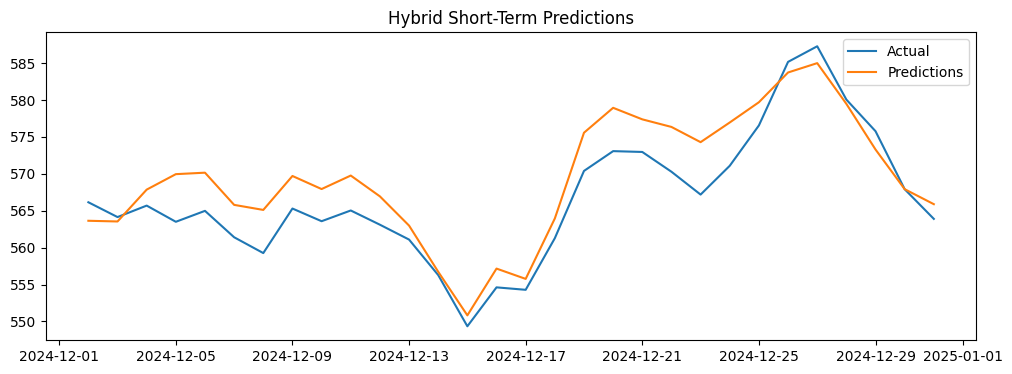


===== HYBRID Long-Term =====
SARIMAX BASE MODEL SUMMARY
                                     SARIMAX Results                                     
Dep. Variable:                  carbon_intensity   No. Observations:                  276
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 7)   Log Likelihood                -601.637
Date:                           Sun, 04 Jan 2026   AIC                           1215.273
Time:                                   12:28:48   BIC                           1236.995
Sample:                               01-01-2024   HQIC                          1223.990
                                    - 10-02-2024                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1            -7.8275      0.286    -27.357      0.000      -8.38

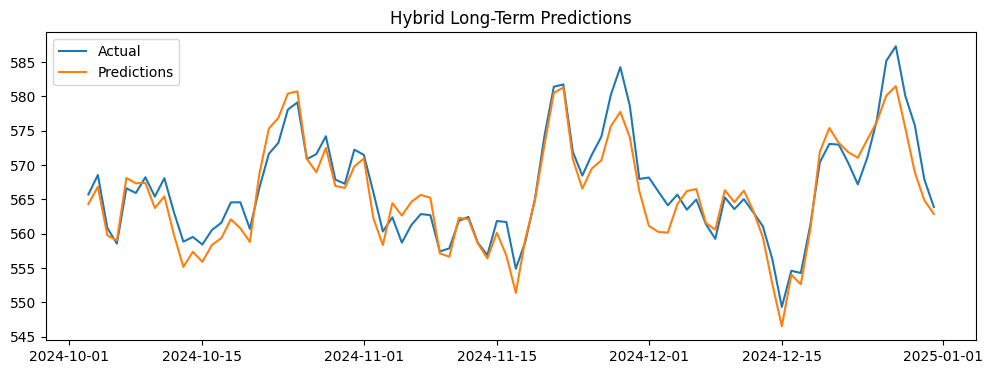

In [14]:
for label, h in HORIZONS.items():
    print(f"\n===== HYBRID {label}-Term =====")

    y_train, y_test, exog_train, exog_test = split_data(y, exog, h)

    sarimax = SARIMAX(
        y_train,
        exog=exog_train,
        order=(1,0,1),
        seasonal_order=(1,0,1,7)
    ).fit()

    print("SARIMAX BASE MODEL SUMMARY")
    print(sarimax.summary())

    sarimax_pred = sarimax.predict(
        start=y_test.index[0],
        end=y_test.index[-1],
        exog=exog_test
    )

    resid = sarimax.resid
    t = np.arange(len(resid))

    resid_model = sm.OLS(resid, sm.add_constant(t)).fit()
    print("RESIDUAL MODEL SUMMARY")
    print(resid_model.summary())

    t_future = np.arange(len(resid), len(resid) + len(y_test))
    resid_forecast = resid_model.predict(sm.add_constant(t_future))

    hybrid_pred = sarimax_pred + resid_forecast

    mae, rmse, mape = evaluate(y_test, hybrid_pred)
    results.append(["Hybrid", label, mae, rmse, mape])

    plt.figure(figsize=(12,4))
    plt.plot(y_test, label="Actual")
    plt.plot(hybrid_pred, label="Predictions")
    plt.title(f"Hybrid {label}-Term Predictions")
    plt.legend()
    plt.show()

#TABEL EVALUASI AKHIR

In [15]:
results_df = pd.DataFrame(
    results,
    columns=["Model", "Horizon", "MAE", "RMSE", "MAPE (%)"]
)

results_df

,Model,Horizon,MAE,RMSE,MAPE (%)
0,SARIMAX,Short,2.259835,2.729377,0.396531
1,SARIMAX,Long,2.042732,2.555032,0.359604
2,TSR,Short,1.731921,2.190006,0.304433
3,TSR,Long,1.775601,2.199542,0.312745
4,Hybrid,Short,3.380943,3.919136,0.596511
5,Hybrid,Long,2.208393,2.740919,0.388637


In [18]:
n_short = 30
n_long = 90

last_date = y.index[-1]

future_30 = pd.date_range(
    start=last_date + pd.Timedelta(days=1),
    periods=n_short,
    freq="D"
)

future_90 = pd.date_range(
    start=last_date + pd.Timedelta(days=1),
    periods=n_long,
    freq="D"
)

# SARIMAX

In [19]:
# Scaling exog SAMA PERSIS
scaler = StandardScaler()
exog_scaled = scaler.fit_transform(exog)

sarimax_final = SARIMAX(
    y,
    exog=exog_scaled,
    order=(1,0,1),
    seasonal_order=(1,0,1,7),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit()

print(sarimax_final.summary())

                                     SARIMAX Results                                     
Dep. Variable:                  carbon_intensity   No. Observations:                  366
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 7)   Log Likelihood                -738.225
Date:                           Sun, 04 Jan 2026   AIC                           1488.450
Time:                                   12:44:34   BIC                           1511.717
Sample:                               01-01-2024   HQIC                          1497.704
                                    - 12-31-2024                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1            -7.2724      0.376    -19.335      0.000      -8.010      -6.535
ar.L1          0.5632      0.098      5.750

In [20]:
cfe_mean = exog["Carbon-free energy percentage (CFE%)"].mean()

exog_future_30 = pd.DataFrame(
    {"Carbon-free energy percentage (CFE%)": [cfe_mean]*n_short},
    index=future_30
)

exog_future_90 = pd.DataFrame(
    {"Carbon-free energy percentage (CFE%)": [cfe_mean]*n_long},
    index=future_90
)

exog_future_30_s = scaler.transform(exog_future_30)
exog_future_90_s = scaler.transform(exog_future_90)

In [21]:
sarimax_fc_30 = sarimax_final.get_forecast(
    steps=n_short,
    exog=exog_future_30_s
).predicted_mean

sarimax_fc_90 = sarimax_final.get_forecast(
    steps=n_long,
    exog=exog_future_90_s
).predicted_mean

sarimax_fc_30.index = future_30
sarimax_fc_90.index = future_90

# TSR

In [22]:
df_tsr_f = df_daily.copy()
df_tsr_f["t"] = np.arange(len(df_tsr_f))
df_tsr_f["lag_1"] = df_tsr_f["carbon_intensity"].shift(1)
df_tsr_f["lag_7"] = df_tsr_f["carbon_intensity"].shift(7)
df_tsr_f = df_tsr_f.dropna()

X = sm.add_constant(
    df_tsr_f[["t","lag_1","lag_7","Carbon-free energy percentage (CFE%)"]]
)
y_tsr = df_tsr_f["carbon_intensity"]

tsr_final = sm.OLS(y_tsr, X).fit()
print(tsr_final.summary())

                            OLS Regression Results                            
Dep. Variable:       carbon_intensity   R-squared:                       0.915
Model:                            OLS   Adj. R-squared:                  0.914
Method:                 Least Squares   F-statistic:                     946.7
Date:                Sun, 04 Jan 2026   Prob (F-statistic):          1.46e-187
Time:                        12:45:52   Log-Likelihood:                -806.09
No. Observations:                 359   AIC:                             1622.
Df Residuals:                     354   BIC:                             1642.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------


In [27]:
def tsr_forecast_future(model, last_df, steps):
    preds = []
    df_last = last_df.copy()

    for _ in range(steps):
        X_next = sm.add_constant(
            df_last[["t","lag_1","lag_7","Carbon-free energy percentage (CFE%)"]].iloc[-1:],
            has_constant="add"
        )

        # FIX UTAMA DI SINI
        y_pred = model.predict(X_next).iloc[0]
        preds.append(y_pred)

        new_row = {
            "carbon_intensity": y_pred,
            "Carbon-free energy percentage (CFE%)": cfe_mean,
            "t": df_last["t"].iloc[-1] + 1,
            "lag_1": y_pred,
            "lag_7": df_last["lag_1"].iloc[-1]
        }

        df_last = pd.concat(
            [df_last, pd.DataFrame([new_row])],
            ignore_index=True
        )

    return preds

In [28]:
tsr_fc_30 = pd.Series(
    tsr_forecast_future(tsr_final, df_tsr_f, n_short),
    index=future_30
)

tsr_fc_90 = pd.Series(
    tsr_forecast_future(tsr_final, df_tsr_f, n_long),
    index=future_90
)

# HYBRID

In [29]:
# ===============================
# HYBRID FINAL FORECAST
# ===============================

# Residual dari SARIMAX final
resid = sarimax_final.resid
t_resid = np.arange(len(resid))

# Model residual (sama persis dengan kode evaluasi kamu)
resid_model_final = sm.OLS(resid, sm.add_constant(t_resid)).fit()

# Forecast residual
resid_fc_30 = resid_model_final.predict(
    sm.add_constant(np.arange(len(resid), len(resid) + n_short))
)

resid_fc_90 = resid_model_final.predict(
    sm.add_constant(np.arange(len(resid), len(resid) + n_long))
)

# Hybrid = SARIMAX + residual forecast
hybrid_fc_30 = sarimax_fc_30 + resid_fc_30
hybrid_fc_90 = sarimax_fc_90 + resid_fc_90

In [30]:
forecast_30 = pd.DataFrame({
    "Tanggal": future_30,
    "SARIMAX": sarimax_fc_30.values,
    "TSR": tsr_fc_30.values,
    "Hybrid": hybrid_fc_30.values
})

forecast_30

,Tanggal,SARIMAX,TSR,Hybrid
0,2025-01-01,566.513003,566.090952,557.161735
1,2025-01-02,566.683035,566.811185,557.254835
2,2025-01-03,566.594709,567.003218,557.089577
3,2025-01-04,567.722462,567.071870,558.140399
4,2025-01-05,569.800637,567.095901,560.141642
5,2025-01-06,566.146730,567.104747,556.410804
6,2025-01-07,565.663795,567.108389,555.850937
7,2025-01-08,566.765960,567.110248,556.876170
8,2025-01-09,566.828415,567.111497,556.861694
9,2025-01-10,566.679504,567.112537,556.635852


In [31]:
forecast_90 = pd.DataFrame({
    "Tanggal": future_90,
    "SARIMAX": sarimax_fc_90.values,
    "TSR": tsr_fc_90.values,
    "Hybrid": hybrid_fc_90.values
})

forecast_90

,Tanggal,SARIMAX,TSR,Hybrid
0,2025-01-01,566.513003,566.090952,557.161735
1,2025-01-02,566.683035,566.811185,557.254835
2,2025-01-03,566.594709,567.003218,557.089577
3,2025-01-04,567.722462,567.071870,558.140399
4,2025-01-05,569.800637,567.095901,560.141642
...,...,...,...,...
85,2025-03-27,566.904653,567.183356,551.014197
86,2025-03-28,566.754615,567.184287,550.787227
87,2025-03-29,567.847782,567.185218,551.803463
88,2025-03-30,569.906685,567.186149,553.785433


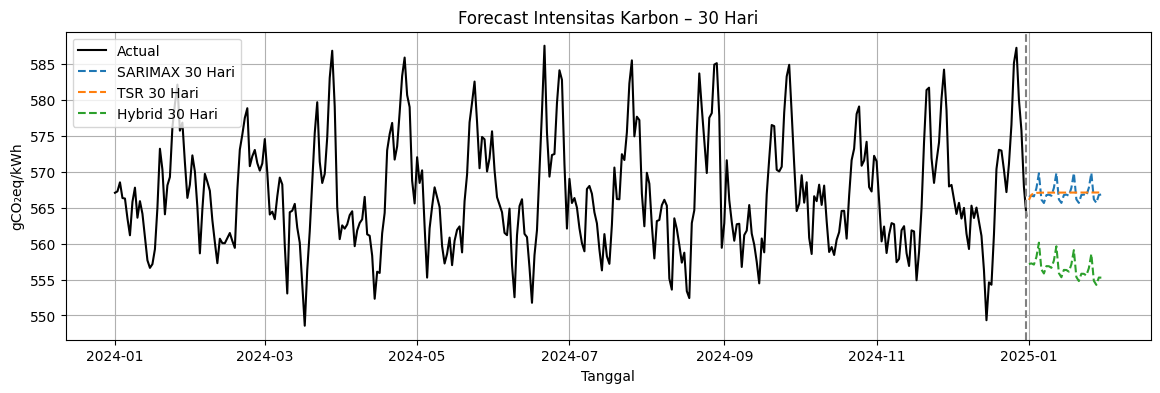

In [32]:
plt.figure(figsize=(14,4))
plt.plot(y, label="Actual", color="black")
plt.plot(sarimax_fc_30, "--", label="SARIMAX 30 Hari")
plt.plot(tsr_fc_30, "--", label="TSR 30 Hari")
plt.plot(hybrid_fc_30, "--", label="Hybrid 30 Hari")
plt.axvline(y.index[-1], color="gray", linestyle="--")
plt.title("Forecast Intensitas Karbon – 30 Hari")
plt.xlabel("Tanggal")
plt.ylabel("gCO₂eq/kWh")
plt.legend()
plt.grid(True)
plt.show()

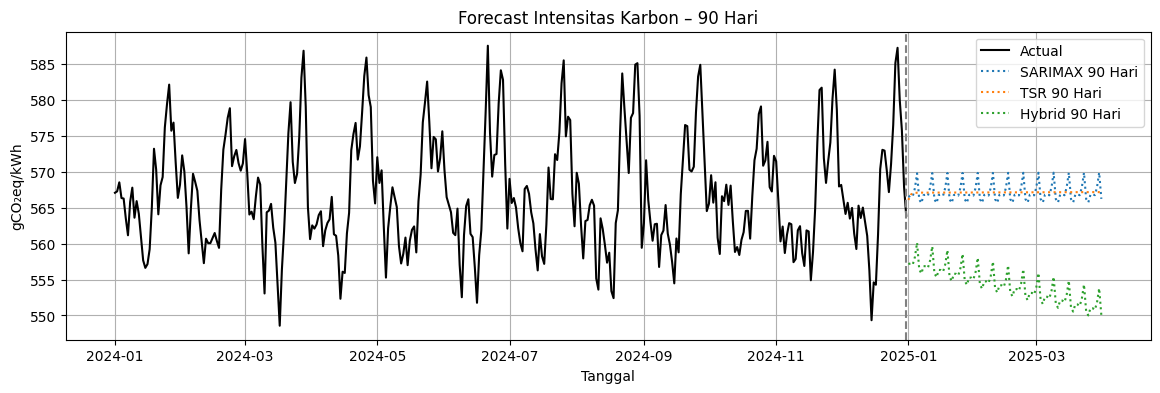

In [33]:
plt.figure(figsize=(14,4))
plt.plot(y, label="Actual", color="black")
plt.plot(sarimax_fc_90, ":", label="SARIMAX 90 Hari")
plt.plot(tsr_fc_90, ":", label="TSR 90 Hari")
plt.plot(hybrid_fc_90, ":", label="Hybrid 90 Hari")
plt.axvline(y.index[-1], color="gray", linestyle="--")
plt.title("Forecast Intensitas Karbon – 90 Hari")
plt.xlabel("Tanggal")
plt.ylabel("gCO₂eq/kWh")
plt.legend()
plt.grid(True)
plt.show()